## 구글 드라이브 마운트

In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/BigContest_JSH/BigContest/data')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 라이브러리

In [ ]:
pip install pycaret

In [ ]:
import pandas as pd
import datetime as dt
import numpy as np
from sklearn.model_selection import train_test_split
from pycaret.classification import *
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler

## 데이터 불러오기

In [ ]:
data = pd.read_csv('data.csv').drop(columns = ['Unnamed: 0.1', 'Unnamed: 0'], errors='ignore')
data


,origin_hdong_cd,dest_hdong_cd,date,start_time,end_time,gender,age,modal,origin_purpose,dest_purpose,od_dist_avg,od_duration_avg,od_cnts,origin_cd,dest_cd
0,3017064000,3020055000,20230908,12,12,0.0,1.0,1.0,5.0,5,9765.0,15.0,58.0,30,30
1,3020054000,3020055000,20230908,11,11,0.0,3.0,1.0,1.0,3,10650.0,15.0,15.0,30,30
2,3017064000,3020055000,20230908,8,8,1.0,2.0,1.0,0.0,4,7084.0,11.0,10.0,30,30
3,3020053000,3020055000,20230908,19,19,1.0,0.0,1.0,3.0,3,14655.0,16.0,21.0,30,30
4,3020060000,3020055000,20230908,12,12,0.0,3.0,1.0,4.0,4,6733.0,9.0,8.0,30,30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11460,1150054000,1156054000,20231007,17,18,0.0,2.0,2.0,0.0,4,58467.0,76.0,5.0,11,11
11461,1156051500,1156054000,20231007,18,19,1.0,4.0,1.0,0.0,3,28704.0,47.0,5.0,11,11
11462,1114062500,1156054000,20231007,17,18,0.0,2.0,2.0,0.0,4,48062.0,81.0,5.0,11,11
11463,1120066000,1156054000,20231007,17,18,0.0,2.0,2.0,5.0,5,69979.0,79.0,5.0,11,11


## 결측치 확인

In [ ]:
data.isna().sum()

,0
origin_hdong_cd,0
dest_hdong_cd,0
date,0
start_time,0
end_time,0
gender,0
age,0
modal,0
origin_purpose,9
dest_purpose,0


## 전처리

In [ ]:
# 컬럼을 숫자 형태(num)와 범주형(category)로 나누기
num_features = ['age', 'od_dist_avg', 'od_duration_avg', 'od_cnts']
cat_features = ['gender', 'modal',  'dest_purpose', 'origin_cd', 'dest_cd']

In [ ]:
# 범주형 변수를 float -> int -> category로 변환
data[cat_features] = data[cat_features].astype('int').astype('category')

In [ ]:
# 데이터 분할: X(독립변수), y(종속변수)
X_data = data[['age', 'od_dist_avg', 'od_duration_avg', 'od_cnts', 'gender', 'modal', 'dest_purpose', 'origin_cd', 'dest_cd']].drop(columns = 'modal')
y_data = data.modal

## Pycaret

In [ ]:
col = X_data.columns

# train, test 데이터 셋 분할
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size = 0.3, random_state = 42)

train_data = pd.DataFrame(X_train, columns = col)
train_data['modal'] = y_train
train_data = train_data.reset_index()

# setup
exp = setup(data = train_data, target = 'modal')
# 모델 비교
best_model = compare_models()
# 성능이 가장 좋은 알고리즘으로 모델 생성(기본 평가 지표: Accuracy)
model = create_model(best_model)
# 모델 생성 마무리
final_model = finalize_model(model)

# y_pred = predict_model(final_model, data = X_test)
# accuracy = accuracy_score(y_test, y_pred['prediction_label'])
# print(f"Accuracy: {accuracy}")

,Description,Value
0,Session id,2716
1,Target,modal
2,Target type,Multiclass
3,Target mapping,"1: 0, 2: 1, 3: 2, 4: 3, 5: 4, 7: 5"
4,Original data shape,"(8025, 10)"
5,Transformed data shape,"(8025, 20)"
6,Transformed train set shape,"(5617, 20)"
7,Transformed test set shape,"(2408, 20)"
8,Numeric features,5
9,Categorical features,4


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,0.8049,0.1826,0.8049,0.8045,0.7989,0.6424,0.6461,1.1480
xgboost,Extreme Gradient Boosting,0.8011,0.1823,0.8011,0.7988,0.7973,0.6404,0.6420,0.8230
gbc,Gradient Boosting Classifier,0.7917,0.0000,0.7917,0.7913,0.7875,0.6197,0.6229,5.3720
et,Extra Trees Classifier,0.7803,0.1796,0.7803,0.7740,0.7730,0.5977,0.6009,0.8830
dt,Decision Tree Classifier,0.7684,0.1602,0.7684,0.7709,0.7686,0.5938,0.5946,0.1700
lightgbm,Light Gradient Boosting Machine,0.7392,0.1706,0.7392,0.7446,0.7407,0.5417,0.5424,2.5330
knn,K Neighbors Classifier,0.6965,0.1523,0.6965,0.6877,0.6870,0.4369,0.4416,0.3370
lda,Linear Discriminant Analysis,0.6936,0.0000,0.6936,0.6749,0.6635,0.4021,0.4179,0.2620
ridge,Ridge Classifier,0.6925,0.0000,0.6925,0.6747,0.6604,0.3981,0.4145,0.1520
lr,Logistic Regression,0.6847,0.0000,0.6847,0.6695,0.6534,0.3853,0.3998,2.4690


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7989,0.0000,0.7989,0.7972,0.7936,0.6331,0.6359
1,0.8238,0.0000,0.8238,0.8284,0.8171,0.6779,0.6806
2,0.8221,0.0000,0.8221,0.8286,0.8169,0.6750,0.6773
3,0.8043,0.0000,0.8043,0.7987,0.8001,0.6494,0.6499
4,0.8060,0.0000,0.8060,0.8108,0.8004,0.6435,0.6479
5,0.8167,0.9251,0.8167,0.8179,0.8095,0.6600,0.6672
6,0.7883,0.9006,0.7883,0.7901,0.7825,0.6073,0.6131
7,0.8093,0.0000,0.8093,0.8114,0.8041,0.6489,0.6539
8,0.7950,0.0000,0.7950,0.7921,0.7903,0.6273,0.6295


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [ ]:
evaluate_model(final_model)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [ ]:
tuned_model = tune_model(final_model)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7562,0.0000,0.7562,0.7713,0.7621,0.5779,0.5785
1,0.7616,0.0000,0.7616,0.7822,0.7678,0.5980,0.6026
2,0.7509,0.0000,0.7509,0.7732,0.7571,0.5788,0.5832
3,0.7527,0.0000,0.7527,0.7763,0.7609,0.5853,0.5892
4,0.7562,0.0000,0.7562,0.7755,0.7626,0.5836,0.5850
5,0.7811,0.9067,0.7811,0.8108,0.7917,0.6341,0.6375
6,0.7456,0.8814,0.7456,0.7632,0.7531,0.5612,0.5619
7,0.7790,0.0000,0.7790,0.7841,0.7804,0.6169,0.6178
8,0.7540,0.0000,0.7540,0.7830,0.7661,0.5845,0.5873


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 10 candidates, totalling 100 fits


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


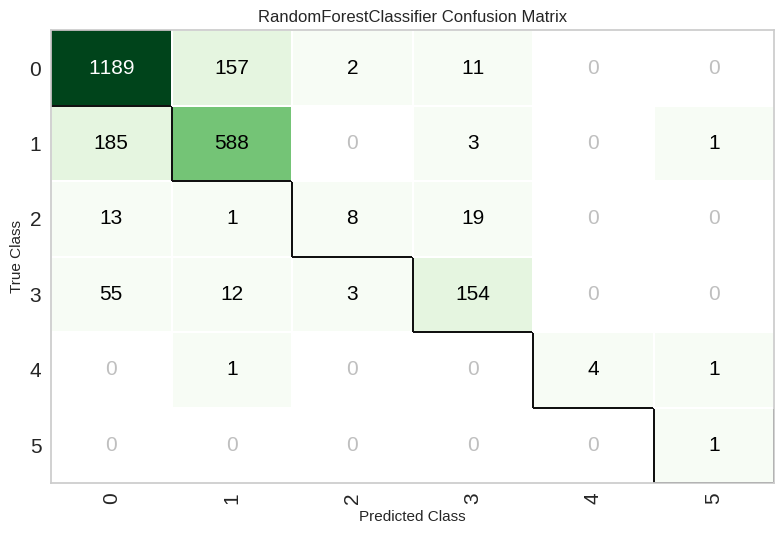

In [ ]:
plot_model(tuned_model, plot = 'confusion_matrix')

Standard Scaler

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import pandas as pd
from pycaret.classification import *

# Train, test 데이터 셋 분할
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.3, random_state=42)

# StandardScaler 적용 (수치형 데이터만)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

# PyCaret 설정 준비
train_data = pd.DataFrame(X_train_scaled, columns=X_train.columns)
train_data['modal'] = y_train.reset_index(drop=True)

# PyCaret setup
exp = setup(data=train_data, target='modal')

# 모델 비교 및 최적 모델 생성
best_model = compare_models()
model = create_model(best_model)

# 모델 마무리
final_model = finalize_model(model)

# 모델 예측 및 정확도 평가
y_pred = predict_model(final_model, data=X_test_scaled)
accuracy = accuracy_score(y_test, y_pred['prediction_label'])
print(f"Accuracy: {accuracy}")


,Description,Value
0,Session id,1871
1,Target,modal
2,Target type,Multiclass
3,Target mapping,"1: 0, 2: 1, 3: 2, 4: 3, 5: 4, 7: 5"
4,Original data shape,"(8025, 9)"
5,Transformed data shape,"(8025, 9)"
6,Transformed train set shape,"(5617, 9)"
7,Transformed test set shape,"(2408, 9)"
8,Numeric features,8
9,Preprocess,True


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,0.8569,0.1881,0.8569,0.8545,0.8534,0.7427,0.7438,0.9280
et,Extra Trees Classifier,0.8483,0.1898,0.8483,0.8466,0.8449,0.7271,0.7284,0.6430
xgboost,Extreme Gradient Boosting,0.8330,0.1855,0.8330,0.8324,0.8308,0.7003,0.7012,0.6080
dt,Decision Tree Classifier,0.8207,0.1730,0.8207,0.8221,0.8208,0.6848,0.6849,0.1060
gbc,Gradient Boosting Classifier,0.7992,0.0000,0.7992,0.7993,0.7954,0.6349,0.6374,3.5120
lightgbm,Light Gradient Boosting Machine,0.7778,0.1743,0.7778,0.7805,0.7778,0.6070,0.6076,3.9110
knn,K Neighbors Classifier,0.7572,0.1734,0.7572,0.7518,0.7480,0.5527,0.5561,0.2110
lr,Logistic Regression,0.7096,0.0000,0.7096,0.7050,0.6792,0.4325,0.4498,0.5500
ridge,Ridge Classifier,0.7006,0.0000,0.7006,0.6256,0.6555,0.4068,0.4272,0.0400
lda,Linear Discriminant Analysis,0.6975,0.0000,0.6975,0.6483,0.6536,0.4001,0.4214,0.0410


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8399,0.0000,0.8399,0.8392,0.8378,0.7118,0.7128
1,0.8594,0.0000,0.8594,0.8551,0.8547,0.7482,0.7487
2,0.8737,0.0000,0.8737,0.8706,0.8709,0.7755,0.7757
3,0.8488,0.0000,0.8488,0.8496,0.8457,0.7245,0.7274
4,0.8523,0.0000,0.8523,0.8505,0.8500,0.7365,0.7368
5,0.8594,0.9358,0.8594,0.8546,0.8523,0.7444,0.7466
6,0.8559,0.9453,0.8559,0.8523,0.8522,0.7424,0.7428
7,0.8699,0.0000,0.8699,0.8692,0.8674,0.7677,0.7681
8,0.8467,0.0000,0.8467,0.8442,0.8440,0.7243,0.7253


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

Accuracy: 0.916860465116279


LabelEncoder


In [ ]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd
from pycaret.classification import *

# Train, test 데이터 셋 분할
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.3, random_state=42)

# Label Encoding 적용 (y_train과 y_test에 대해)
encoder = LabelEncoder()
y_train_encoded = encoder.fit_transform(y_train)
y_test_encoded = encoder.transform(y_test)

# StandardScaler 적용 (수치형 데이터만)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

# PyCaret 설정 준비
train_data = pd.DataFrame(X_train_scaled, columns=X_train.columns)
train_data['modal'] = y_train_encoded

# PyCaret setup
exp = setup(data=train_data, target='modal')

# 모델 비교 및 최적 모델 생성
best_model = compare_models()
model = create_model(best_model)

# 모델 마무리
final_model = finalize_model(model)

# 모델 예측 및 정확도 평가
y_pred = predict_model(final_model, data=X_test_scaled)
accuracy = accuracy_score(y_test_encoded, y_pred['prediction_label'])
print(f"Accuracy: {accuracy}")


,Description,Value
0,Session id,2037
1,Target,modal
2,Target type,Multiclass
3,Original data shape,"(8025, 9)"
4,Transformed data shape,"(8025, 9)"
5,Transformed train set shape,"(5617, 9)"
6,Transformed test set shape,"(2408, 9)"
7,Numeric features,8
8,Preprocess,True
9,Imputation type,simple


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,0.8647,0.1865,0.8647,0.8650,0.8625,0.7577,0.7588,0.5860
et,Extra Trees Classifier,0.8530,0.1874,0.8530,0.8518,0.8506,0.7374,0.7382,0.5300
xgboost,Extreme Gradient Boosting,0.8389,0.1843,0.8389,0.8386,0.8372,0.7118,0.7126,0.3790
dt,Decision Tree Classifier,0.8241,0.1673,0.8241,0.8269,0.8245,0.6927,0.6935,0.0480
gbc,Gradient Boosting Classifier,0.8061,0.0000,0.8061,0.8073,0.8026,0.6471,0.6498,3.4820
knn,K Neighbors Classifier,0.7597,0.1714,0.7597,0.7546,0.7507,0.5577,0.5610,0.1330
lightgbm,Light Gradient Boosting Machine,0.7582,0.1641,0.7582,0.7620,0.7593,0.5766,0.5772,2.5050
lr,Logistic Regression,0.7114,0.0000,0.7114,0.7044,0.6853,0.4398,0.4554,0.2110
ridge,Ridge Classifier,0.6986,0.0000,0.6986,0.6240,0.6535,0.4027,0.4235,0.0350
lda,Linear Discriminant Analysis,0.6959,0.0000,0.6959,0.6333,0.6517,0.3972,0.4187,0.0640


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8612,0.0000,0.8612,0.8637,0.8605,0.7543,0.7553
1,0.8648,0.0000,0.8648,0.8655,0.8645,0.7620,0.7621
2,0.8772,0.0000,0.8772,0.8792,0.8748,0.7779,0.7801
3,0.8648,0.0000,0.8648,0.8651,0.8635,0.7584,0.7590
4,0.8630,0.0000,0.8630,0.8649,0.8583,0.7524,0.7542
5,0.8505,0.9337,0.8505,0.8477,0.8483,0.7334,0.7338
6,0.8523,0.9309,0.8523,0.8499,0.8487,0.7357,0.7362
7,0.8645,0.0000,0.8645,0.8660,0.8629,0.7574,0.7580
8,0.8717,0.0000,0.8717,0.8709,0.8698,0.7694,0.7700


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

Accuracy: 0.9197674418604651


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd
from pycaret.classification import *

# Train, test 데이터 셋 분할
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.3, random_state=42)

# OneHotEncoding 적용 (범주형 변수에 대해)
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)

# 원본 train, test와 get_dummies 이후 결과 비교
print("Original X_train (first 5 rows):")
print(X_train.head())  # 원본 X_train 출력
print("\nOneHotEncoded X_train (first 5 rows):")
print(X_train_encoded.head())  # get_dummies 후 X_train 출력

# 만약 X_test에 없는 범주형 변수 열이 생기면, 그 차이를 맞춰야 함
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

# StandardScaler 적용 (수치형 데이터만 스케일링, 범주형 변환 이후)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_encoded), columns=X_train_encoded.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_encoded), columns=X_train_encoded.columns)

# StandardScaler 결과 확인 (X_train)
print("\nScaled X_train (first 5 rows):")
print(X_train_scaled.head())  # 스케일링 후 X_train 출력

# PyCaret 설정 준비
train_data = pd.DataFrame(X_train_scaled, columns=X_train_scaled.columns)
train_data['modal'] = y_train.reset_index(drop=True)

# PyCaret setup
exp = setup(data=train_data, target='modal')

# 모델 비교 및 최적 모델 생성
best_model = compare_models()
model = create_model(best_model)

# 모델 마무리
final_model = finalize_model(model)

# 모델 예측 및 정확도 평가
y_pred = predict_model(final_model, data=X_test_scaled)
accuracy = accuracy_score(y_test, y_pred['prediction_label'])
print(f"Accuracy: {accuracy}")


Original X_train (first 5 rows):
       age  od_dist_avg  od_duration_avg  od_cnts gender dest_purpose  \
3526   1.0      12395.0              7.0      6.0      0            4   
1483   2.0      35555.0             48.0      5.0      1            4   
3827   1.0       4046.0             13.0      6.0      0            4   
11194  2.0      87907.0             99.0      7.0      0            4   
6315   4.0      46416.0             65.0      5.0      1            5   

      origin_cd dest_cd  
3526         51      51  
1483         26      26  
3827         51      51  
11194        11      11  
6315         11      11  

OneHotEncoded X_train (first 5 rows):
       age  od_dist_avg  od_duration_avg  od_cnts  gender_1  dest_purpose_4  \
3526   1.0      12395.0              7.0      6.0     False            True   
1483   2.0      35555.0             48.0      5.0      True            True   
3827   1.0       4046.0             13.0      6.0     False            True   
11194  2.0      8

,Description,Value
0,Session id,6534
1,Target,modal
2,Target type,Multiclass
3,Target mapping,"1: 0, 2: 1, 3: 2, 4: 3, 5: 4, 7: 5"
4,Original data shape,"(8025, 16)"
5,Transformed data shape,"(8025, 16)"
6,Transformed train set shape,"(5617, 16)"
7,Transformed test set shape,"(2408, 16)"
8,Numeric features,15
9,Preprocess,True


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,0.8592,0.1876,0.8592,0.8570,0.8555,0.7474,0.7485,0.6420
et,Extra Trees Classifier,0.8467,0.1884,0.8467,0.8443,0.8437,0.7258,0.7267,0.6580
xgboost,Extreme Gradient Boosting,0.8307,0.1845,0.8307,0.8301,0.8280,0.6955,0.6971,0.4330
dt,Decision Tree Classifier,0.8259,0.1704,0.8259,0.8276,0.8257,0.6949,0.6957,0.0930
gbc,Gradient Boosting Classifier,0.8010,0.0000,0.8010,0.8038,0.7974,0.6373,0.6405,3.8710
lightgbm,Light Gradient Boosting Machine,0.7760,0.1656,0.7760,0.7788,0.7765,0.6065,0.6070,2.5090
knn,K Neighbors Classifier,0.7627,0.1742,0.7627,0.7557,0.7525,0.5627,0.5666,0.1300
lr,Logistic Regression,0.7075,0.0000,0.7075,0.7013,0.6795,0.4309,0.4467,0.1560
svm,SVM - Linear Kernel,0.6934,0.0000,0.6934,0.6681,0.6570,0.3955,0.4154,0.2620
ridge,Ridge Classifier,0.6911,0.0000,0.6911,0.6663,0.6557,0.3933,0.4109,0.0820


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8381,0.0000,0.8381,0.8356,0.8357,0.7114,0.7119
1,0.8488,0.0000,0.8488,0.8479,0.8470,0.7307,0.7310
2,0.8719,0.0000,0.8719,0.8689,0.8679,0.7677,0.7702
3,0.8648,0.0000,0.8648,0.8660,0.8612,0.7592,0.7596
4,0.8701,0.0000,0.8701,0.8714,0.8661,0.7669,0.7683
5,0.8683,0.9370,0.8683,0.8675,0.8632,0.7611,0.7635
6,0.8505,0.9393,0.8505,0.8442,0.8463,0.7319,0.7327
7,0.8574,0.0000,0.8574,0.8529,0.8525,0.7432,0.7440
8,0.8627,0.0000,0.8627,0.8608,0.8605,0.7542,0.7549


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

Accuracy: 0.9174418604651163


OneHotEncoder

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import pandas as pd

# Train, test 데이터 셋 분할
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.3, random_state=42)

# StandardScaler 객체 생성
scaler = StandardScaler()

# Train 데이터에 대해 StandardScaler 적용
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)

# Test 데이터에 대해 StandardScaler 적용 (fit 없이 transform만)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

# 원본 데이터와 스케일된 데이터 비교 (X_train)
print("Original X_train (first 5 rows):")
print(X_train.head())  # 원본 X_train 출력

print("\nScaled X_train (first 5 rows):")
print(X_train_scaled.head())  # 스케일링 후 X_train 출력

# Test 데이터의 변환 후 값도 필요하면 출력 가능
print("\nOriginal X_test (first 5 rows):")
print(X_test.head())  # 원본 X_test 출력

print("\nScaled X_test (first 5 rows):")
print(X_test_scaled.head())  # 스케일링 후 X_test 출력


Original X_train (first 5 rows):
       age  od_dist_avg  od_duration_avg  od_cnts gender dest_purpose  \
3526   1.0      12395.0              7.0      6.0      0            4   
1483   2.0      35555.0             48.0      5.0      1            4   
3827   1.0       4046.0             13.0      6.0      0            4   
11194  2.0      87907.0             99.0      7.0      0            4   
6315   4.0      46416.0             65.0      5.0      1            5   

      origin_cd dest_cd  
3526         51      51  
1483         26      26  
3827         51      51  
11194        11      11  
6315         11      11  

Scaled X_train (first 5 rows):
        age  od_dist_avg  od_duration_avg   od_cnts    gender  dest_purpose  \
0 -0.777120    -0.452441        -1.047279 -0.373060 -1.268093      0.084096   
1 -0.046522     0.117398         0.282677 -0.557272  0.788586      0.084096   
2 -0.777120    -0.657863        -0.852652 -0.373060 -1.268093      0.084096   
3 -0.046522     1.405490